<!--
Copyright (c) 2025-2026, NVIDIA CORPORATION. All rights reserved.

Licensed under the Apache License, Version 2.0 (the "License");
you may not use this file except in compliance with the License.
You may obtain a copy of the License at

 http://www.apache.org/licenses/LICENSE-2.0

Unless required by applicable law or agreed to in writing, software
distributed under the License is distributed on an "AS IS" BASIS,
WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
See the License for the specific language governing permissions and
limitations under the License.
-->

# Aim
The purpose of this notebook is to show how to use JIT to tune a FLUX model.

In [ ]:
%%capture
%load_ext autoreload
%autoreload 2
%cd ../..
%pwd
%pip install diffusers<=0.34.0 transformers>=4.54,<5 matplotlib

In [ ]:
from aitune.torch.jit.patcher import patch_for_jit_tuning
from aitune.torch.jit.patched_module import PatchedModule
from aitune.torch.jit.config import config
import torch

from diffusers import FluxPipeline
from notebooks.jit.jit_commons import visualize_latency, benchmark
from PIL import Image

prompt = "A fluffy, orange tabby cat with bright green eyes is captured mid-air, pouncing playfully on a vibrant red ball of yarn"

Unable to import quantization op. Please install modelopt library (https://github.com/NVIDIA/TensorRT-Model-Optimizer?tab=readme-ov-file#installation) to add support for compiling quantized models
TensorRT-LLM is not installed. Please install TensorRT-LLM or set TRTLLM_PLUGINS_PATH to the directory containing libnvinfer_plugin_tensorrt_llm.so to use converters for torch.distributed ops


[08/06/2025-07:50:22] [TRT] [W] Functionality provided through tensorrt.plugin module is experimental.


  from .autonotebook import tqdm as notebook_tqdm



# FLUX

In [ ]:
config.dry_run = False
config.min_samples = 10
config.max_depth_level = 1
config.detect_graph_breaks = True
# config.skip_modules = ["FluxTransformer2DModel"]

In [ ]:
@patch_for_jit_tuning
def create_model():
    pipe = FluxPipeline.from_pretrained("black-forest-labs/FLUX.1-dev", torch_dtype=torch.float16).to(device="cuda", dtype=torch.float16)
    torch.cuda.empty_cache()
    return pipe

In [5]:
model = create_model()

Loading pipeline components...: 100%|██████████| 7/7 [00:04<00:00,  1.43it/s]


100%|██████████| 1/1 [00:00<00:00,  2.74it/s]
07:51:38.004 - INFO - ------------------------------------------------------------
07:51:38.005 - INFO - 🚀 Tuning graph `0` for module `CLIPTextModel 📊123.1M`:
07:51:38.005 - INFO -   number of parameters: 123.1M
07:51:38.006 - INFO -   number of layers: 1
07:51:38.006 - INFO -   precisions: torch.float16
07:51:38.006 - INFO -   graph_spec:
07:51:38.007 - INFO -     input_spec: ((input__0[dim0, 77] min_shape=[1, 77] max_shape=[2, 77] dtype=torch.int64,), {output_hidden_states: False})
07:51:38.007 - INFO -     output_spec: {last_hidden_state: output__0[dim0, 77, 768] min_shape=[1, 77, 768] max_shape=[2, 77, 768] dtype=torch.float16, pooler_output: output__1[dim0, 768] min_shape=[1, 768] max_shape=[2, 768] dtype=torch.float16}
07:51:38.008 - INFO -   num samples: 1
07:51:38.008 - INFO -   device: cuda
07:51:38.008 - INFO -   cache_dir: /home/vscode/.cache/aitune.jit/1e34ef9d813d110661e8593091811b15e49cd031da152f571cb83357b5be9b01/0
07:51:38.

[W] 'colored' module is not installed, will not use colors when logging. To enable colors, please install the 'colored' module: python3 -m pip install colored


07:51:58.151 - Level 28 - [I] Finished engine building in 12.163 seconds
07:51:58.270 - INFO - [I] Saving engine to /home/vscode/.cache/aitune.jit/1e34ef9d813d110661e8593091811b15e49cd031da152f571cb83357b5be9b01/0/TensorRTBackend/af74c28a036db3019c5a3923d6c2511e1d3083af4ef6c8f99fea2628d19ad0f2/model.plan
07:51:59.694 - INFO -     ✅ backend built
07:51:59.703 - INFO -     ✅ backend validated
07:51:59.703 - INFO - 🎯 Strategy JitStrategy execution finished in 21.69s.
07:51:59.704 - INFO - ✅ Selected backend: TensorRTBackend(precision=fp16)


[08/06/2025-07:51:59] [TRT] [I] Loaded engine size: 236 MiB
[08/06/2025-07:51:59] [TRT] [I] [MemUsageChange] TensorRT-managed allocation in IExecutionContext creation: CPU +0, GPU +3, now: CPU 0, GPU 237 (MiB)


07:52:18.828 - INFO - ------------------------------------------------------------
07:52:18.829 - INFO - 🚀 Tuning graph `0` for module `T5EncoderModel 📊4.8B`:
07:52:18.830 - INFO -   number of parameters: 4.8B
07:52:18.830 - INFO -   number of layers: 2
07:52:18.830 - INFO -   precisions: torch.float16
07:52:18.831 - INFO -   graph_spec:
07:52:18.831 - INFO -     input_spec: ((input__0[dim0, 512] min_shape=[1, 512] max_shape=[2, 512] dtype=torch.int64,), {output_hidden_states: False})
07:52:18.831 - INFO -     output_spec: {last_hidden_state: output__0[dim0, 512, 4096] min_shape=[1, 512, 4096] max_shape=[2, 512, 4096] dtype=torch.float16}
07:52:18.831 - INFO -   num samples: 1
07:52:18.832 - INFO -   device: cuda
07:52:18.832 - INFO -   cache_dir: /home/vscode/.cache/aitune.jit/5e3237de056c0d9bbf0db97729fa63254435cc0c9827368f935ea78bf559077e/0
07:52:18.832 - INFO -   strategy:
07:52:18.832 - INFO -     name: JIT Strategy
07:52:18.833 - INFO -     description: tailored for JIT tuning, t

...

08:06:01.202 - INFO -     ✅ backend built
08:06:01.503 - INFO -     ✅ backend validated
08:06:01.504 - INFO - 🎯 Strategy JitStrategy execution finished in 10m 34s.
08:06:01.504 - INFO - ✅ Selected backend: TensorRTBackend(precision=fp16)
100%|██████████| 1/1 [11:39<00:00, 699.35s/it]
08:06:16.399 - INFO - ------------------------------------------------------------
08:06:16.400 - INFO - 🚀 Tuning graph `0` for module `Decoder 📊49.5M`:
08:06:16.400 - INFO -   number of parameters: 49.5M
08:06:16.401 - INFO -   number of layers: 6
08:06:16.401 - INFO -   precisions: torch.float16
08:06:16.401 - INFO -   graph_spec:
08:06:16.401 - INFO -     input_spec: ((input__0[dim0, 16, 128, 128] min_shape=[1, 16, 128, 128] max_shape=[2, 16, 128, 128] dtype=torch.float16,), {})
08:06:16.402 - INFO -     output_spec: output__0[dim0, 3, 1024, 1024] min_shape=[1, 3, 1024, 1024] max_shape=[2, 3, 1024, 1024] dtype=torch.float16
08:06:16.402 - INFO -   num samples: 1
08:06:16.402 - INFO -   device: cuda
08:0

[08/06/2025-08:10:53] [TRT] [I] The logger passed into createInferRuntime differs from one already provided for an existing builder, runtime, or refitter. Uses of the global logger, returned by nvinfer1::getLogger(), will return the existing value.
[08/06/2025-08:10:53] [TRT] [I] Loaded engine size: 99 MiB
[08/06/2025-08:10:53] [TRT] [I] [MemUsageChange] TensorRT-managed allocation in IExecutionContext creation: CPU +0, GPU +5280, now: CPU 0, GPU 38653 (MiB)


08:10:53.957 - INFO -     ❌ backend failed due to inf/nan values. Retrying with fp32 precision
08:10:53.960 - INFO - ⚙️ backend:  TensorRTBackend(precision=fp32)
08:10:53.961 - INFO -     🔄 in progress...please wait
08:11:01.022 - INFO - [I] Configuring with profiles:[
        Profile 0:
            {input__0 [min=(1, 16, 128, 128), opt=(2, 16, 128, 128), max=(2, 16, 128, 128)]}
    ]
08:11:01.025 - Level 22 - [I] Building engine with configuration:
    Flags                  | [TF32]
    Engine Capability      | EngineCapability.STANDARD
    Memory Pools           | [WORKSPACE: 80995.06 MiB, TACTIC_DRAM: 80995.06 MiB, TACTIC_SHARED_MEMORY: 1024.00 MiB]
    Tactic Sources         | [EDGE_MASK_CONVOLUTIONS, JIT_CONVOLUTIONS]
    Profiling Verbosity    | ProfilingVerbosity.DETAILED
    Preview Features       | [PROFILE_SHARING_0806]
08:13:59.890 - Level 28 - [I] Finished engine building in 178.865 seconds
08:14:00.011 - INFO - [I] Saving engine to /home/vscode/.cache/aitune.jit/9d00ec94e

[08/06/2025-08:14:01] [TRT] [I] The logger passed into createInferRuntime differs from one already provided for an existing builder, runtime, or refitter. Uses of the global logger, returned by nvinfer1::getLogger(), will return the existing value.
[08/06/2025-08:14:01] [TRT] [I] Loaded engine size: 196 MiB
[08/06/2025-08:14:01] [TRT] [I] [MemUsageChange] TensorRT-managed allocation in IExecutionContext creation: CPU +0, GPU +9601, now: CPU 0, GPU 43068 (MiB)


08:14:01.881 - INFO -     ✅ backend validated
08:14:01.882 - INFO - 🎯 Strategy JitStrategy execution finished in 7m 45s.
08:14:01.882 - INFO - ✅ Selected backend: TensorRTBackend(precision=fp32)
100%|██████████| 1/1 [00:00<00:00,  2.02it/s]


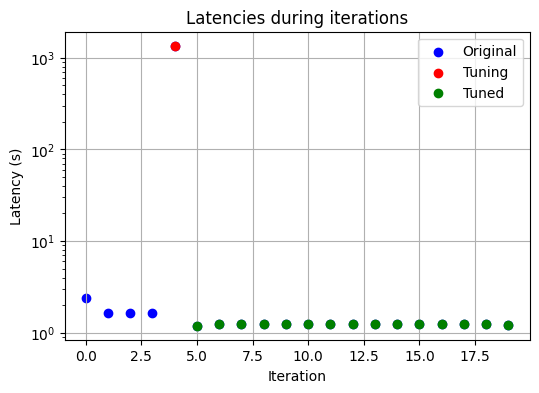

In [ ]:
def batch():
    with torch.no_grad():
        model(["liquid robot"] * 1, num_inference_steps=1)
        model(["liquid robot"] * 2, num_inference_steps=1)

visualize_latency(lambda: batch(), iterations=20)

In [7]:
PatchedModule.history

['New top module: CLIPTextModel 📊123.1M level=0🪜 state=init⏳ call_count=1',
 'New top module: T5EncoderModel 📊4.8B level=0🪜 state=init⏳ call_count=1',
 'New top module: FluxTransformer2DModel 📊11.9B level=0🪜 state=init⏳ call_count=1',
 'New top module: Decoder 📊49.5M level=0🪜 state=init⏳ call_count=1',
 'No graph breaks in CLIPTextModel 📊123.1M. Checking took 9.47s',
 'Tuning CLIPTextModel 📊123.1M took 21.70s',
 'Model tuned: CLIPTextModel 📊123.1M level=0🪜 state=tuned🎯 (TensorRTBackend) call_count=10',
 'No graph breaks in T5EncoderModel 📊4.8B. Checking took 19.06s',
 'Tuning T5EncoderModel 📊4.8B took 123.33s',
 'Model tuned: T5EncoderModel 📊4.8B level=0🪜 state=tuned🎯 (TensorRTBackend) call_count=10',
 'No graph breaks in FluxTransformer2DModel 📊11.9B. Checking took 64.73s',
 'Tuning FluxTransformer2DModel 📊11.9B took 633.88s',
 'Model tuned: FluxTransformer2DModel 📊11.9B level=0🪜 state=tuned🎯 (TensorRTBackend) call_count=10',
 'No graph breaks in Decoder 📊49.5M. Checking took 14.68s',

In [8]:
PatchedModule.print_hierarchy()

PatchedModule Hierarchy:
├─ CLIPTextModel 📊123.1M level=0🪜 state=tuned🎯 (TensorRTBackend) call_count=10
├─ T5EncoderModel 📊4.8B level=0🪜 state=tuned🎯 (TensorRTBackend) call_count=10
├─ FluxTransformer2DModel 📊11.9B level=0🪜 state=tuned🎯 (TensorRTBackend) call_count=10
├─ Decoder 📊49.5M level=0🪜 state=tuned🎯 (TensorRTBackend) call_count=10


In [9]:
resp = model([prompt])

  0%|          | 0/28 [00:00<?, ?it/s]

100%|██████████| 28/28 [00:07<00:00,  3.87it/s]


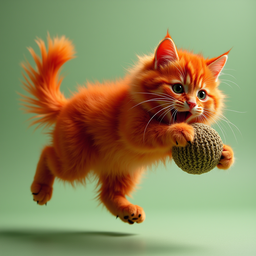

In [10]:
# resize image so that it does no take much space in notebook
img = resp["images"][0]
img_resized = img.resize((256, 256), Image.LANCZOS)
img_resized

# Benchmark

## Tuned model

In [ ]:
benchmark(lambda: model([prompt]), iterations=10)

  4%|▎         | 1/28 [00:00<00:06,  3.96it/s]

100%|██████████| 28/28 [00:07<00:00,  3.85it/s]


'7.4s ± 0.0187 (10 iterations)'

## Original model

In [ ]:
model = FluxPipeline.from_pretrained("black-forest-labs/FLUX.1-dev", torch_dtype=torch.float16).to(device="cuda", dtype=torch.float16)
torch.cuda.empty_cache()

Loading pipeline components...: 100%|██████████| 7/7 [00:11<00:00,  1.58s/it]


In [ ]:
benchmark(lambda: model([prompt]), iterations=10)

  0%|          | 0/28 [00:00<?, ?it/s]

100%|██████████| 28/28 [00:10<00:00,  2.62it/s]


'11.0s ± 0.0555 (10 iterations)'